In [26]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

### Does spatial information from a nearby buoy (44095) improve forecasting at the target station

In [2]:
na_vals = [99, 999, 9999, 99999]

def read_ndbc_stdmet(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        header = None
        for line in f:
            if line.startswith("#YY"):
                header = line.lstrip("#").strip().split()
                break
    if header is None:
        raise ValueError(f"Couldn't find #YY header in {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=header,
        na_values=na_vals,
        engine="python",
    )
    return df

def build_station_df(station_prefix):
    files = sorted(glob.glob(f"{station_prefix}*.txt"))  
    dfs = [read_ndbc_stdmet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    # make datetime
    df = df.rename(columns={"YY":"year","MM":"month","DD":"day","hh":"hour","mm":"minute"})
    df["datetime"] = pd.to_datetime(df[["year","month","day","hour","minute"]], errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    return df

target = build_station_df("41025h")   # target station
nbr    = build_station_df("44095h")   # nearby station


In [3]:
target_hr = target.resample("1H").mean()
nbr_hr    = nbr.resample("1H").mean()

C:\Users\attafuro\AppData\Local\Temp\ipykernel_80564\3150706141.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_hr = target.resample("1H").mean()
C:\Users\attafuro\AppData\Local\Temp\ipykernel_80564\3150706141.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  nbr_hr    = nbr.resample("1H").mean()


In [12]:
cols_keep = ["WVHT","APD","DPD","WSPD","GST","PRES","ATMP"] 

target_x = target_hr[cols_keep].add_suffix("_T")   # T = target station
nbr_x    = nbr_hr[cols_keep].add_suffix("_N")      # N = neighbor station

merged = target_x.join(nbr_x, how="inner")  # aligned timestamps only


In [13]:
merged.shape


(52584, 14)

In [17]:
merged.head()

,WVHT_T,APD_T,DPD_T,WSPD_T,GST_T,PRES_T,ATMP_T,WVHT_N,APD_N,DPD_N,WSPD_N,GST_N,PRES_N,ATMP_N
datetime,,,,,,,,,,,,,,
2014-01-01 00:00:00,0.96,4.40,6.25,6.8,9.5,1026.6,11.8,0.915,4.175,6.275,NaN,NaN,NaN,NaN
2014-01-01 01:00:00,0.89,4.23,5.88,7.5,9.5,1027.6,11.9,0.840,4.155,6.250,NaN,NaN,NaN,NaN
2014-01-01 02:00:00,0.89,4.15,5.88,6.6,9.4,1027.9,11.7,0.790,4.040,6.460,NaN,NaN,NaN,NaN
2014-01-01 03:00:00,0.92,4.38,6.25,7.0,10.1,1027.9,12.0,0.735,3.905,6.250,NaN,NaN,NaN,NaN
2014-01-01 04:00:00,0.94,4.21,5.88,5.2,7.2,1027.7,11.7,0.745,3.945,6.065,NaN,NaN,NaN,NaN


In [7]:
heat_df = pd.concat(
    [
        target_hr[["WVHT", "APD"]].add_suffix("_T"),
        nbr_hr[["WVHT", "APD"]].add_suffix("_N")
    ],
    axis=1
).dropna()


In [8]:
corr_mat = heat_df.corr()
corr_mat


,WVHT_T,APD_T,WVHT_N,APD_N
WVHT_T,1.000000,0.486012,0.863664,0.411787
APD_T,0.486012,1.000000,0.490354,0.785547
WVHT_N,0.863664,0.490354,1.000000,0.507013
APD_N,0.411787,0.785547,0.507013,1.000000


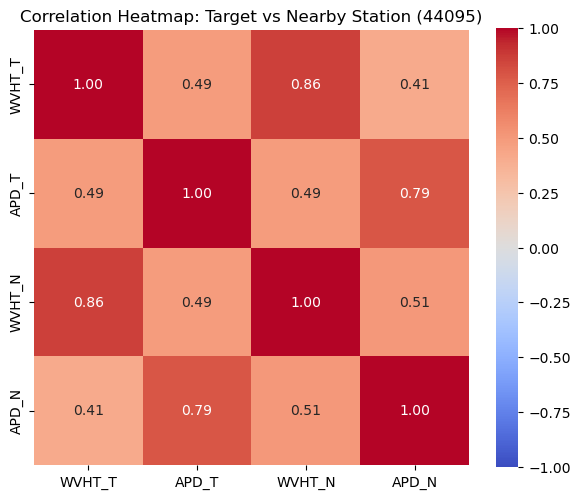

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Heatmap: Target vs Nearby Station (44095)")
plt.tight_layout()
plt.show()


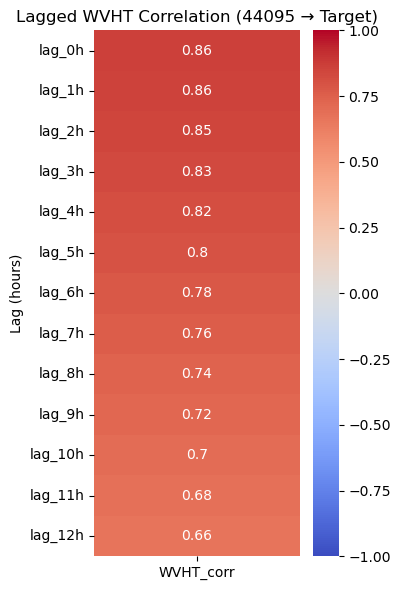

In [10]:
lags = range(0, 13)  # 0–12 hours
lag_corrs = {}

for lag in lags:
    lag_corrs[f"lag_{lag}h"] = heat_df["WVHT_T"].corr(
        heat_df["WVHT_N"].shift(lag)
    )

lag_df = pd.DataFrame.from_dict(lag_corrs, orient="index", columns=["WVHT_corr"])

plt.figure(figsize=(4,6))
sns.heatmap(lag_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Lagged WVHT Correlation (44095 → Target)")
plt.ylabel("Lag (hours)")
plt.tight_layout()
plt.show()


## Model Building 

## Wave Height 

In [18]:
X_cols = ["WSPD_T", "GST_T", "APD_T", "PRES_T", "ATMP_T", "WVHT_N", "APD_N"]
y_col = "WVHT_T"

# Keep ONLY what we need
df = merged[X_cols + [y_col]].copy()

# Only require the target to be present.
df = df.dropna(subset=[y_col])

for c in X_cols + [y_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[y_col])  # in case coercion created NaNs
df.shape


(44274, 8)

In [22]:
# =========================
# Time-based split (train first 80%, test last 20%)
# =========================
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test,  y_test  = test_df[X_cols],  test_df[y_col]

len(train_df), len(test_df)

(35419, 8855)

In [23]:
# =========================
# Preprocessing (impute missing neighbor values, scale when needed)
# =========================

numeric_features = X_cols

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

preprocess_no_scale = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features)
    ],
    remainder="drop"
)


In [27]:
# =========================
# Define models (like the paper-style ML baselines)
# =========================
models = {}

#  Linear Regression
models["LinearRegression"] = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", LinearRegression())
])

# KNN Regressor
models["KNN"] = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", KNeighborsRegressor(n_neighbors=15))
])

# Decision Tree
models["DecisionTree"] = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=None))
])

# Random Forest
models["RandomForest"] = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    ))
])

# XGBoost
models["XGBoost"] = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

# Stacking Regressor (classic “paper-like” ensemble)
base_estimators = [
    ("lr",  Pipeline(steps=[("prep", preprocess_scaled), ("model", LinearRegression())])),
    ("rf",  Pipeline(steps=[("prep", preprocess_no_scale), ("model", RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1))])),
    ("xgb", Pipeline(steps=[("prep", preprocess_no_scale), ("model", XGBRegressor(n_estimators=350, learning_rate=0.06, max_depth=5, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1))]))
]

models["Stacking"] = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression(),
    passthrough=False
)


In [29]:
# =========================
#Train + Evaluate (MAE, RMSE, R²) on the time-based test split
# =========================

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # manual RMSE
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


results = []
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    preds[name] = yhat

    mae, rmse, r2 = evaluate(y_test, yhat)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
results_df


,Model,MAE,RMSE,R2
5,Stacking,0.157608,0.240766,0.919988
3,RandomForest,0.165854,0.255721,0.909740
4,XGBoost,0.164259,0.256703,0.909046
1,KNN,0.182006,0.283070,0.889401
0,LinearRegression,0.204070,0.287319,0.886056
2,DecisionTree,0.233781,0.338624,0.841730


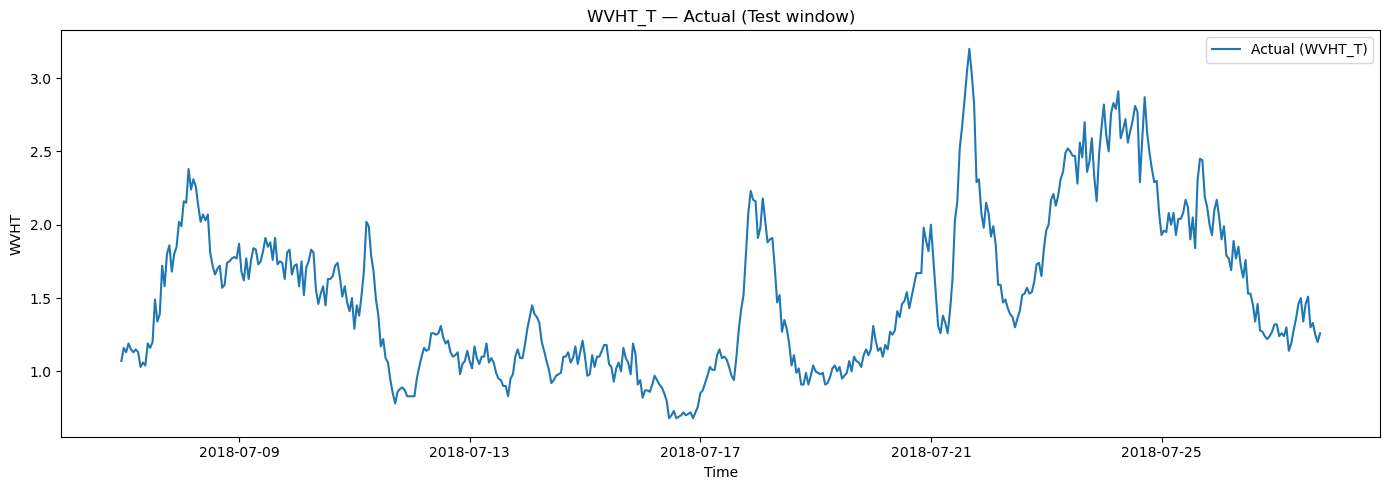

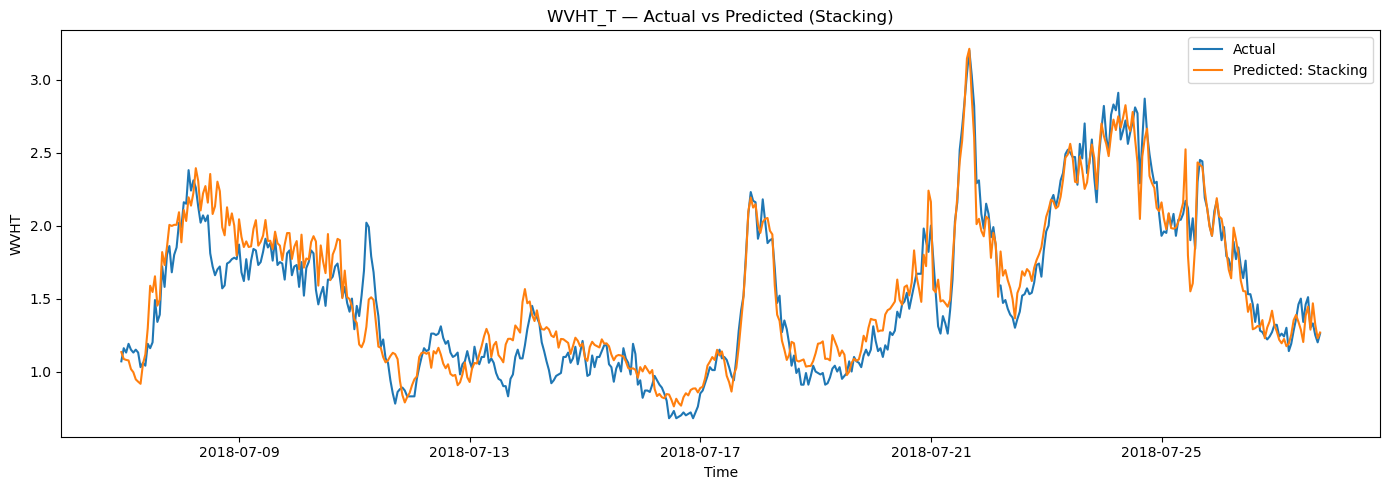

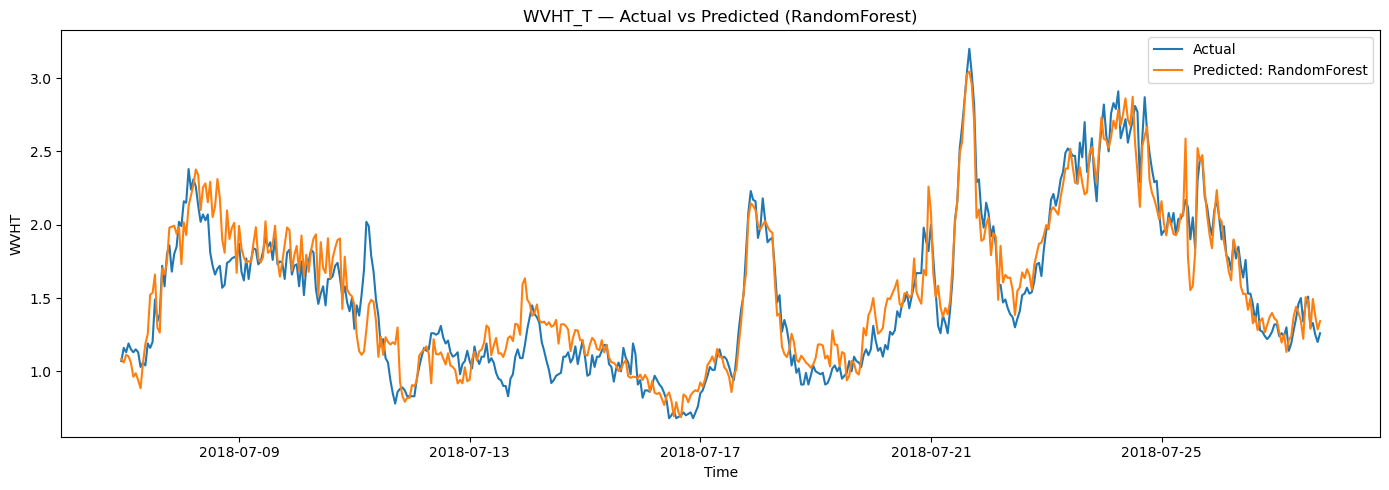

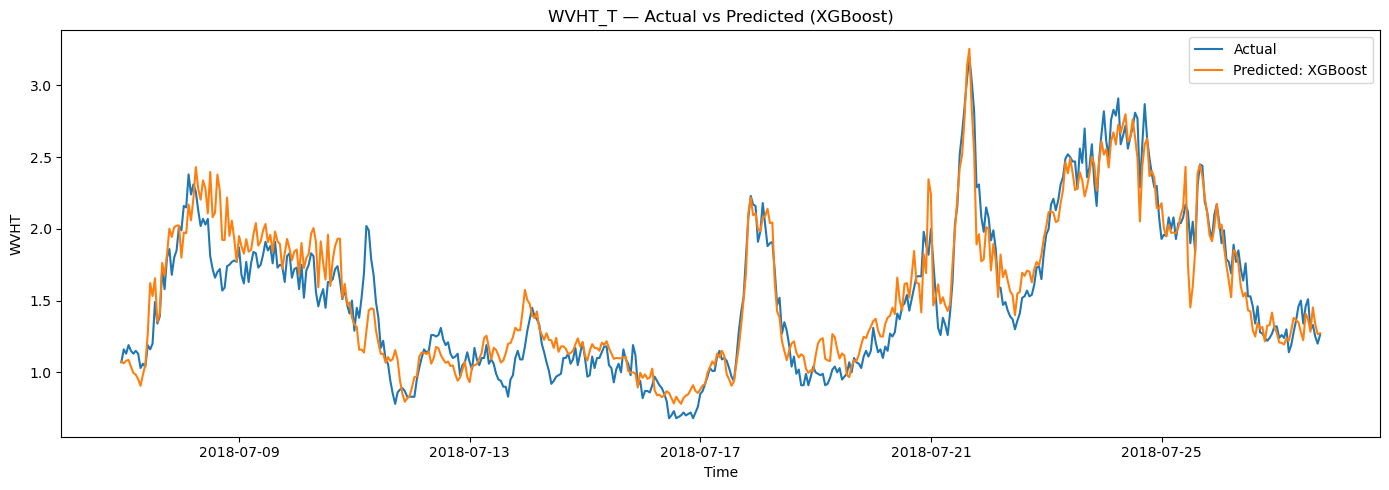

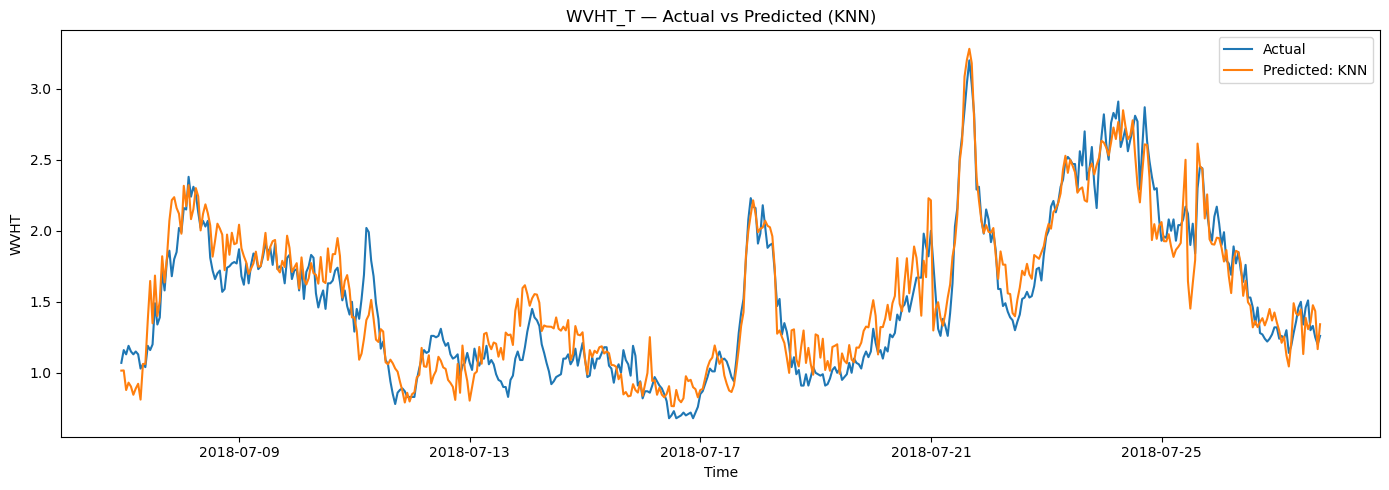

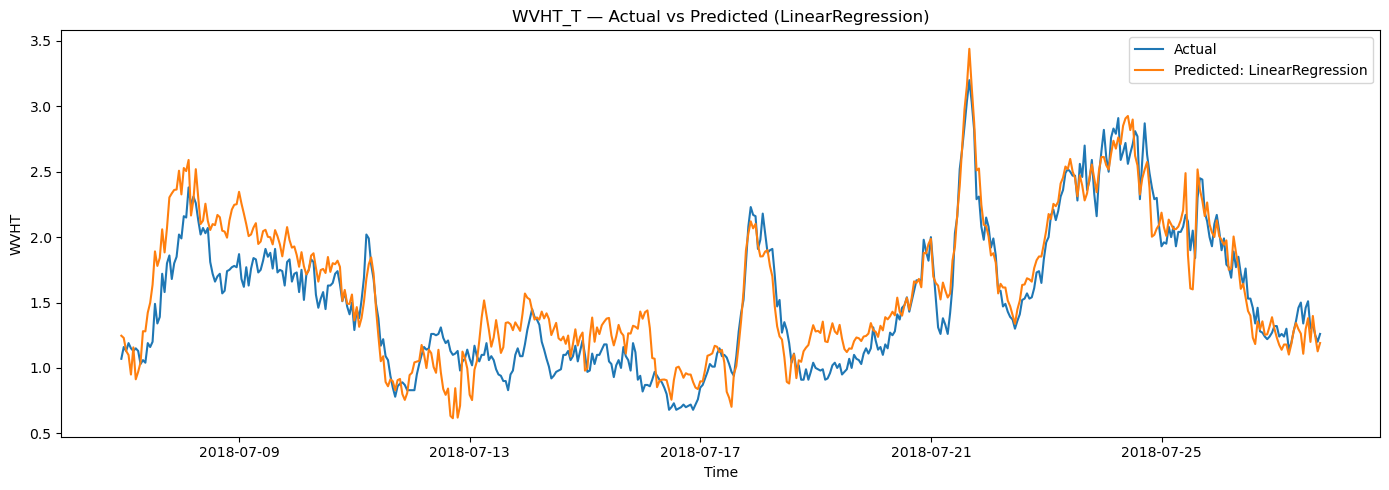

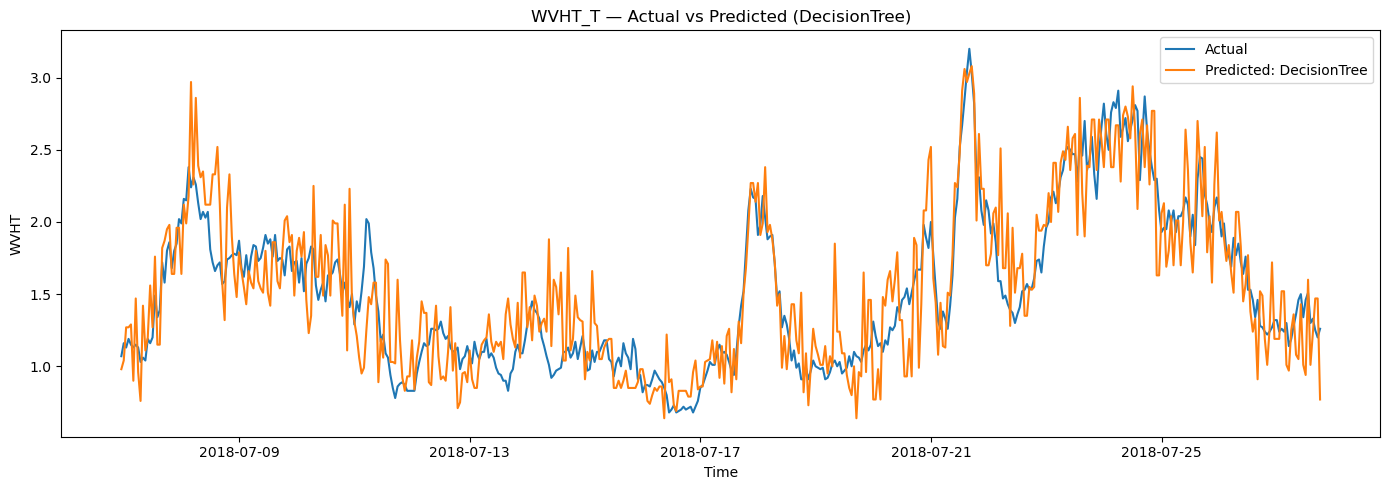

In [30]:
N = 500  # change to 1000 if you want a longer view
t = test_df.index[:N]
y_true = y_test.iloc[:N].values

plt.figure(figsize=(14,5))
plt.plot(t, y_true, label="Actual (WVHT_T)")
plt.title("WVHT_T — Actual (Test window)")
plt.xlabel("Time")
plt.ylabel("WVHT")
plt.legend()
plt.tight_layout()
plt.show()

for name in results_df["Model"].tolist():
    plt.figure(figsize=(14,5))
    plt.plot(t, y_true, label="Actual")
    plt.plot(t, preds[name][:N], label=f"Predicted: {name}")
    plt.title(f"WVHT_T — Actual vs Predicted ({name})")
    plt.xlabel("Time")
    plt.ylabel("WVHT")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [31]:
# =========================
out = pd.DataFrame(index=test_df.index)
out["WVHT_T_Actual"] = y_test

for name, yhat in preds.items():
    out[f"WVHT_T_Pred_{name}"] = yhat

out.to_excel("WVHT_T_Predictions_with_Neighbor.xlsx")
print("Saved: WVHT_T_Predictions_with_Neighbor.xlsx")


Saved: WVHT_T_Predictions_with_Neighbor.xlsx


## Adding  lag-1 neighbor features (WVHT_N, APD_N)

In [33]:
# Create lag-1 features for neighbor station
merged["WVHT_N_lag1"] = merged["WVHT_N"].shift(1)
merged["APD_N_lag1"]  = merged["APD_N"].shift(1)


In [34]:
X_cols_lag = [
    "WSPD_T",
    "GST_T",
    "APD_T",
    "PRES_T",
    "ATMP_T",
    "WVHT_N",
    "APD_N",
    "WVHT_N_lag1",
    "APD_N_lag1"
]

y_col = "WVHT_T"

df_lag = merged[X_cols_lag + [y_col]].copy()

# Only require the target to exist
df_lag = df_lag.dropna(subset=[y_col])

# Coerce to numeric (safe)
for c in X_cols_lag + [y_col]:
    df_lag[c] = pd.to_numeric(df_lag[c], errors="coerce")

df_lag = df_lag.dropna(subset=[y_col])

df_lag.shape


(44274, 10)

In [35]:
split_idx = int(len(df_lag) * 0.8)

train_df = df_lag.iloc[:split_idx]
test_df  = df_lag.iloc[split_idx:]

X_train, y_train = train_df[X_cols_lag], train_df[y_col]
X_test,  y_test  = test_df[X_cols_lag],  test_df[y_col]

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (35419, 9) Test: (8855, 9)


In [36]:
results_lag = []
preds_lag = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    preds_lag[name] = yhat

    mae, rmse, r2 = evaluate(y_test, yhat)
    results_lag.append([name, mae, rmse, r2])

results_lag_df = pd.DataFrame(
    results_lag, columns=["Model", "MAE", "RMSE", "R2"]
).sort_values("RMSE")

results_lag_df


,Model,MAE,RMSE,R2
5,Stacking,0.157608,0.240766,0.919988
3,RandomForest,0.165854,0.255721,0.909740
4,XGBoost,0.164259,0.256703,0.909046
1,KNN,0.182006,0.283070,0.889401
0,LinearRegression,0.204070,0.287319,0.886056
2,DecisionTree,0.233781,0.338624,0.841730


In [38]:
comparison = results_df.merge(
    results_lag_df,
    on="Model",
    suffixes=("_Spatial", "_SpatialLag")
)

comparison


,Model,MAE_Spatial,RMSE_Spatial,R2_Spatial,MAE_SpatialLag,RMSE_SpatialLag,R2_SpatialLag
0,Stacking,0.157608,0.240766,0.919988,0.157608,0.240766,0.919988
1,RandomForest,0.165854,0.255721,0.909740,0.165854,0.255721,0.909740
2,XGBoost,0.164259,0.256703,0.909046,0.164259,0.256703,0.909046
3,KNN,0.182006,0.283070,0.889401,0.182006,0.283070,0.889401
4,LinearRegression,0.204070,0.287319,0.886056,0.204070,0.287319,0.886056
5,DecisionTree,0.233781,0.338624,0.841730,0.233781,0.338624,0.841730


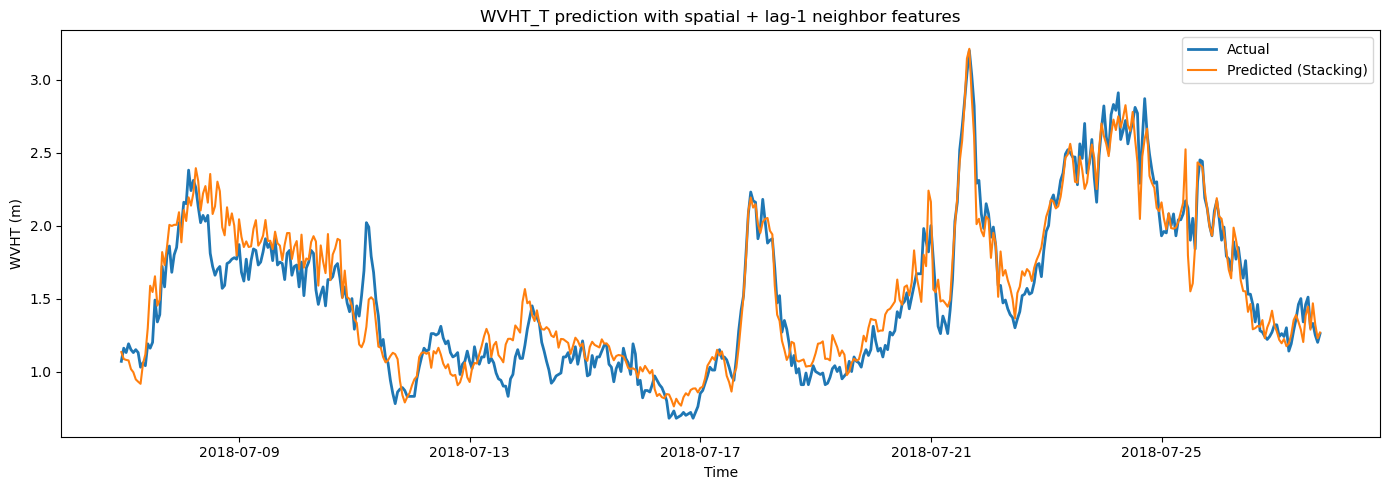

In [39]:
N = 500
t = test_df.index[:N]
y_true = y_test.iloc[:N].values

plt.figure(figsize=(14,5))
plt.plot(t, y_true, label="Actual", linewidth=2)

best_model = results_lag_df.iloc[0]["Model"]
plt.plot(t, preds_lag[best_model][:N], label=f"Predicted ({best_model})")

plt.title("WVHT_T prediction with spatial + lag-1 neighbor features")
plt.xlabel("Time")
plt.ylabel("WVHT (m)")
plt.legend()
plt.tight_layout()
plt.show()


## AVERAGE WIND PERIOD